In [1]:
#get all the tables:
from db_setup import conn, currencyexchange, customer, date, product, sales, store
#instead of saving csv files in sql and then importing one by one
import pandas as pd

customer_summary=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_summary.parquet")
rfm=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\rfm.parquet")
customer_value_segments=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_value_segments.parquet")
order_enriched=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\order_enriched.parquet")


c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  currencyexchange = pd.read_sql("SELECT * FROM currencyexchange", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer = pd.read_sql("SELECT * FROM customer", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  date = pd.read_sql("SELECT * FR

distinct customer-month activity:

In [2]:
cohort = order_enriched.merge(
    customer_summary[["customerkey", "cohort_month"]],
    on="customerkey"
)


cohort["cohort_month"] = cohort["cohort_month"].dt.to_period("M")
cohort["order_month"] = cohort["orderdate"].dt.to_period("M")

cohort["months_number"] = (
    (cohort["order_month"].dt.year * 12 + cohort["order_month"].dt.month)
    - (cohort["cohort_month"].dt.year * 12 + cohort["cohort_month"].dt.month)
)

cohort_month_activity = cohort[["customerkey", "cohort_month", "months_number"]].drop_duplicates()

In [3]:
cohort_month_activity
#cohort_month is of period[M] type

,customerkey,cohort_month,months_number
0,947009,2015-01,0
1,1772036,2015-01,0
2,1518349,2015-01,0
3,1317097,2015-01,0
4,254117,2015-01,0
...,...,...,...
83125,1692049,2020-02,50
83126,852158,2022-09,19
83127,635184,2015-02,110
83128,664396,2024-04,0


cohort_size:

In [ ]:
cohort_size = (
    customer_summary
    .groupby("cohort_month")
    .agg(cohort_size=("customerkey", "nunique"))
    .reset_index()
)

cohort_size["cohort_month"]=cohort_size["cohort_month"].dt.to_period("M")


cohort_size

#cohort_month is of period[M] type

,cohort_month,cohort_size
0,2015-01,200
1,2015-02,290
2,2015-03,138
3,2015-04,77
4,2015-05,235
...,...,...
107,2023-12,515
108,2024-01,442
109,2024-02,595
110,2024-03,292


rolling retention

In [ ]:
rolling_rows = []

for cohort_month, group in cohort_month_activity.groupby("cohort_month"):

    max_month = group["months_number"].max()
    
    for month in range(0, max_month + 1):

        retained_customers = group.loc[group["months_number"] >= month, "customerkey"].nunique()
        
        rolling_rows.append({
            "cohort_month": cohort_month,
            "months_number": month,
            "retained_customers": retained_customers
        })


rolling_retention = pd.DataFrame(rolling_rows)

In [6]:
rolling_retention

,cohort_month,months_number,retained_customers
0,2015-01,0,200
1,2015-01,1,117
2,2015-01,2,116
3,2015-01,3,116
4,2015-01,4,116
...,...,...,...
6286,2024-02,1,14
6287,2024-02,2,4
6288,2024-03,0,292
6289,2024-03,1,1


merge cohort size and get the rate:

In [7]:
rolling_retention = rolling_retention.merge(
    cohort_size,
    on="cohort_month",
    how="left"
)

rolling_retention["rolling_retention_rate"] = (
    rolling_retention["retained_customers"] /
    rolling_retention["cohort_size"]
)

In [8]:
rolling_retention

,cohort_month,months_number,retained_customers,cohort_size,rolling_retention_rate
0,2015-01,0,200,200,1.000000
1,2015-01,1,117,200,0.585000
2,2015-01,2,116,200,0.580000
3,2015-01,3,116,200,0.580000
4,2015-01,4,116,200,0.580000
...,...,...,...,...,...
6286,2024-02,1,14,595,0.023529
6287,2024-02,2,4,595,0.006723
6288,2024-03,0,292,292,1.000000
6289,2024-03,1,1,292,0.003425


heatmap

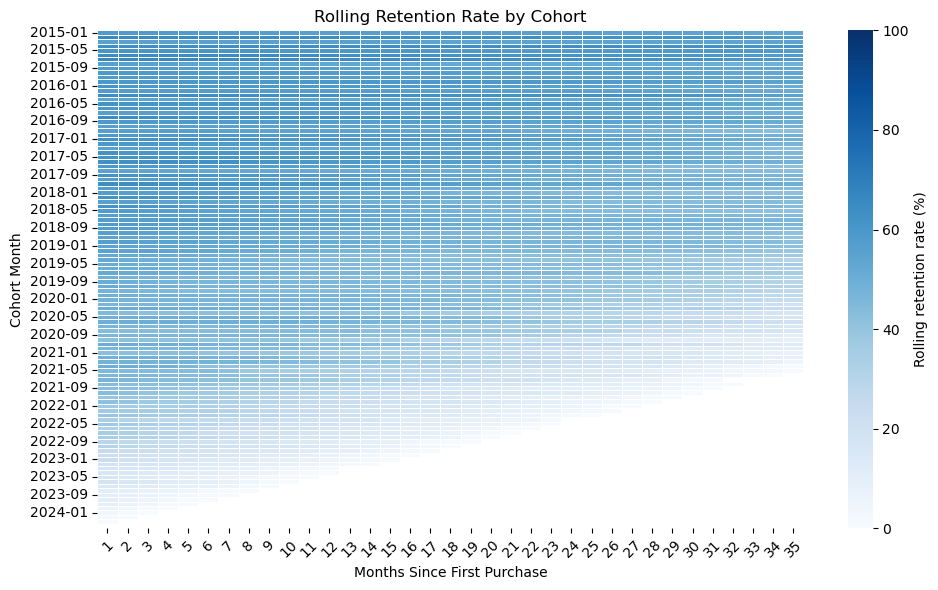

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

rolling_pivot = rolling_retention.pivot_table(
    index="cohort_month",
    columns="months_number",
    values="rolling_retention_rate"
)

rolling_pivot = rolling_pivot * 100
rolling_pivot = rolling_pivot.sort_index()

plt.figure(figsize=(10, 6))

sns.heatmap(
    rolling_pivot.iloc[:, 1:36],
    annot=False,
    cmap="Blues",
    linewidths=0.5,
    vmin=0,
    vmax=100
)

plt.gca().collections[0].colorbar.set_label("Rolling retention rate (%)")

plt.xticks(rotation=45)
plt.title("Rolling Retention Rate by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()


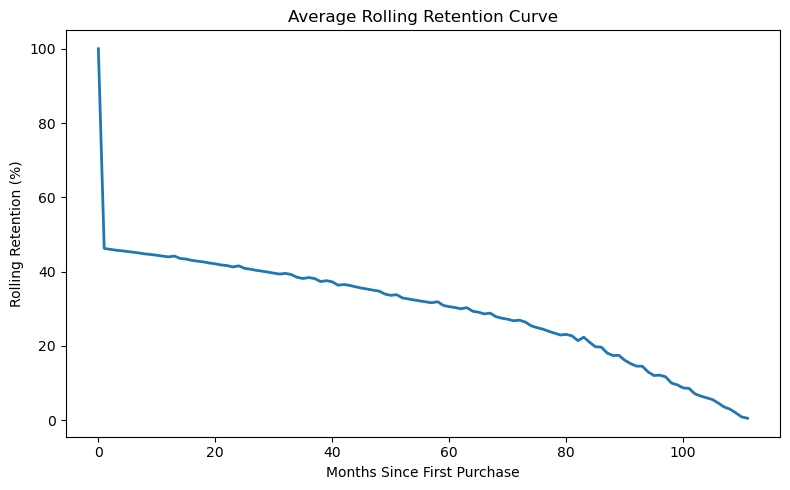

In [11]:
avg_curve = (
    rolling_retention
    .groupby("months_number")["rolling_retention_rate"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    avg_curve["months_number"],
    avg_curve["rolling_retention_rate"] * 100,
    linewidth=2
)

plt.xlabel("Months Since First Purchase")
plt.ylabel("Rolling Retention (%)")
plt.title("Average Rolling Retention Curve")

plt.tight_layout()

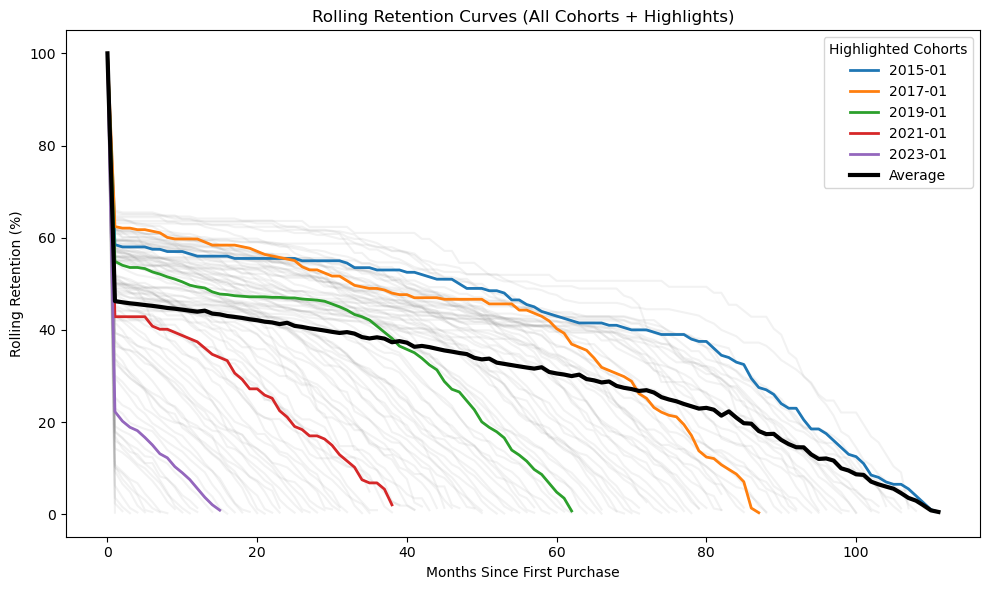

In [19]:
plt.figure(figsize=(10,6))

# plot ALL cohorts (faded)
for cohort in rolling_retention["cohort_month"].unique():
    subset = rolling_retention[
        rolling_retention["cohort_month"] == cohort
    ].sort_values("months_number")
    
    plt.plot(
        subset["months_number"],
        subset["rolling_retention_rate"] * 100,
        color="gray",
        alpha=0.1
    )

# highlight selected cohorts
selected = [
    pd.Period("2015-01", freq="M"),
    pd.Period("2017-01", freq="M"),
    pd.Period("2019-01", freq="M"),
    pd.Period("2021-01", freq="M"),
    pd.Period("2023-01", freq="M"),
]

for cohort in selected:
    subset = rolling_retention[
        rolling_retention["cohort_month"] == cohort
    ].sort_values("months_number")
    
    plt.plot(
        subset["months_number"],
        subset["rolling_retention_rate"] * 100,
        linewidth=2,
        label=str(cohort)
    )

avg_curve = (
    rolling_retention
    .groupby("months_number")["rolling_retention_rate"]
    .mean()
    .reset_index()
)

plt.plot(
    avg_curve["months_number"],
    avg_curve["rolling_retention_rate"] * 100,
    color="black",
    linewidth=3,
    label="Average"
)

plt.xlabel("Months Since First Purchase")
plt.ylabel("Rolling Retention (%)")
plt.title("Rolling Retention Curves (All Cohorts + Highlights)")
plt.legend(title="Highlighted Cohorts")

plt.tight_layout()